# 🥔 SSD (Single Shot Detector) — Potato Disease Detection
### Classes: Early Blight | Late Blight | Healthy
---

## Step 1: Mount Google Drive & Unzip Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Install Dependencies

In [6]:
!pip install sympy==1.13.1 --quiet
import importlib
import sys

# Remove cached sympy modules so the new version loads cleanly
mods_to_remove = [k for k in sys.modules if 'sympy' in k]
for mod in mods_to_remove:
    del sys.modules[mod]

print("sympy fixed! Now re-run Step 3 imports cell.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 62.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires sympy>=1.13.3, but you have sympy 1.13.1 which is incompatible.
sympy fixed! Now re-run Step 3 imports cell.


In [7]:
!pip install torch torchvision --quiet
!pip install pycocotools --quiet
!pip install matplotlib opencv-python-headless tqdm torchmetrics --quiet
print('All dependencies installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 45.0 MB/s eta 0:00:00
All dependencies installed!


## Step 3: Imports & Configuration

In [1]:
import os
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision.models.detection.ssdlite import SSDLite320_MobileNet_V3_Large_Weights

# UPDATE these paths based on your dataset structure
DATASET_PATH  = '/content/drive/MyDrive/btp_2_alt.v3i.yolov11'
TRAIN_IMG_DIR = os.path.join(DATASET_PATH, 'train', 'images')
TRAIN_LBL_DIR = os.path.join(DATASET_PATH, 'train', 'labels')
VAL_IMG_DIR   = os.path.join(DATASET_PATH, 'valid', 'images')
VAL_LBL_DIR   = os.path.join(DATASET_PATH, 'valid', 'labels')
TEST_IMG_DIR  = os.path.join(DATASET_PATH, 'test',  'images')
TEST_LBL_DIR  = os.path.join(DATASET_PATH, 'test',  'labels')

CLASSES      = ['Early_Blight', 'Late_Blight']
NUM_CLASSES  = len(CLASSES) + 1  # +1 for background
BATCH_SIZE   = 8
NUM_EPOCHS   = 30
LR           = 1e-4
IMG_SIZE     = 320
CONF_THRESH  = 0.4
IOU_THRESH   = 0.5
SAVE_PATH    = '/content/drive/MyDrive/ssd_potato_best.pth'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Classes: {CLASSES}')
print(f'Num classes (incl. background): {NUM_CLASSES}')

Device: cuda
Classes: ['Early_Blight', 'Late_Blight']
Num classes (incl. background): 3


## Step 4: Custom Dataset (YOLO Format)

In [2]:
class PotatoDiseaseDataset(Dataset):
    def __init__(self, img_dir, lbl_dir, transforms=None):
        self.img_dir    = Path(img_dir)
        self.lbl_dir    = Path(lbl_dir)
        self.transforms = transforms
        self.img_files  = sorted([
            f for f in self.img_dir.iterdir()
            if f.suffix.lower() in ('.jpg', '.jpeg', '.png')
        ])
        print(f'  Found {len(self.img_files)} images in {img_dir}')

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        lbl_path = self.lbl_dir / (img_path.stem + '.txt')

        img = Image.open(img_path).convert('RGB')
        orig_w, orig_h = img.size  # capture BEFORE any transform

        boxes, labels = [], []
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f.read().strip().splitlines():
                    parts = line.split()
                    if len(parts) != 5:
                        continue
                    cls, cx, cy, bw, bh = map(float, parts)
                    # YOLO normalized -> absolute in original image space
                    x1 = max(0, (cx - bw / 2) * orig_w)
                    y1 = max(0, (cy - bh / 2) * orig_h)
                    x2 = min(orig_w, (cx + bw / 2) * orig_w)
                    y2 = min(orig_h, (cy + bh / 2) * orig_h)
                    if x2 > x1 and y2 > y1:
                        boxes.append([x1, y1, x2, y2])
                        labels.append(int(cls) + 1)

        # Apply transforms (resizes image to IMG_SIZE x IMG_SIZE)
        if self.transforms:
            img = self.transforms(img)

        # Scale boxes from original size -> IMG_SIZE
        scale_x = IMG_SIZE / orig_w
        scale_y = IMG_SIZE / orig_h

        if len(boxes) == 0:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,),   dtype=torch.int64)
        else:
            boxes  = torch.tensor(boxes, dtype=torch.float32)
            boxes[:, 0] *= scale_x
            boxes[:, 1] *= scale_y
            boxes[:, 2] *= scale_x
            boxes[:, 3] *= scale_y
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {'boxes': boxes, 'labels': labels, 'image_id': torch.tensor([idx])}
        return img, target


def get_transforms(train=True):
    t = [T.Resize((IMG_SIZE, IMG_SIZE))]
    if train:
        t += [T.RandomHorizontalFlip(0.5),
              T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
              T.RandomRotation(10)]
    t += [T.ToTensor()]
    return T.Compose(t)


def collate_fn(batch):
    return tuple(zip(*batch))


print('Loading datasets...')
train_dataset = PotatoDiseaseDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, get_transforms(True))
val_dataset   = PotatoDiseaseDataset(VAL_IMG_DIR,   VAL_LBL_DIR,   get_transforms(False))
test_dataset  = PotatoDiseaseDataset(TEST_IMG_DIR,  TEST_LBL_DIR,  get_transforms(False))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Loading datasets...
  Found 960 images in /content/drive/MyDrive/btp_2_alt.v3i.yolov11/train/images
  Found 40 images in /content/drive/MyDrive/btp_2_alt.v3i.yolov11/valid/images
  Found 40 images in /content/drive/MyDrive/btp_2_alt.v3i.yolov11/test/images
Train: 960 | Val: 40 | Test: 40


## Step 5: Build SSD Model

In [3]:
def build_ssd_model(num_classes):
    from torchvision.models.detection.ssdlite import SSDLiteClassificationHead
    from functools import partial
    import torch.nn as nn

    # Load full pretrained SSD (91 COCO classes) — backbone matches perfectly
    model = ssdlite320_mobilenet_v3_large(
        weights=SSDLite320_MobileNet_V3_Large_Weights.DEFAULT
    )

    # Each block: Sequential( Conv2dNormActivation(Conv2d, BN, ReLU), Conv2d )
    # in_channels = first Conv2d inside Conv2dNormActivation = seq[0][0].in_channels
    in_channels = [
        seq[0][0].in_channels
        for seq in model.head.classification_head.module_list
    ]
    num_anchors = model.anchor_generator.num_anchors_per_location()

    # Replace classification head only — backbone stays fully pretrained
    model.head.classification_head = SSDLiteClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes,
        norm_layer=partial(nn.BatchNorm2d, eps=0.001, momentum=0.03),
    )

    print('Pretrained SSD loaded. Head replaced for', num_classes, 'classes.')
    return model


model = build_ssd_model(NUM_CLASSES).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total:,} | Trainable: {trainable:,}')

Pretrained SSD loaded. Head replaced for 3 classes.
Total params: 2,220,380 | Trainable: 2,220,380


## Step 6: Training

In [4]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')


def run_epoch(model, loader, optimizer=None):
    model.train()
    total = 0
    for imgs, targets in tqdm(loader, leave=False):
        imgs    = [img.to(DEVICE) for img in imgs]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        if all(t['boxes'].shape[0] == 0 for t in targets):
            continue
        loss_dict = model(imgs, targets)
        loss = sum(loss_dict.values())
        if optimizer:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        total += loss.item()
    return total / len(loader)


print('Starting Training...')
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss = run_epoch(model, train_loader, optimizer)
    with torch.no_grad():
        val_loss = run_epoch(model, val_loader)
    scheduler.step()
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}] Train: {train_loss:.4f} Val: {val_loss:.4f} ({time.time()-t0:.1f}s)')
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  Best model saved (val_loss={val_loss:.4f})')
print('Training complete!')

Starting Training...


Epoch [01/30] Train: 5.4538 Val: 4.8408 (30.2s)
  Best model saved (val_loss=4.8408)


Epoch [02/30] Train: 3.1001 Val: 3.3473 (26.6s)
  Best model saved (val_loss=3.3473)


Epoch [03/30] Train: 1.9142 Val: 2.6849 (27.0s)
  Best model saved (val_loss=2.6849)


Epoch [04/30] Train: 1.4497 Val: 2.4129 (25.7s)
  Best model saved (val_loss=2.4129)


...

Epoch [26/30] Train: 0.5093 Val: 2.3799 (24.2s)


Epoch [27/30] Train: 0.5040 Val: 2.3762 (26.6s)


Epoch [28/30] Train: 0.4774 Val: 2.3914 (26.1s)


Epoch [29/30] Train: 0.4749 Val: 2.3906 (25.4s)


Epoch [30/30] Train: 0.4734 Val: 2.3938 (25.4s)
Training complete!


## Step 7: Plot Training Curves

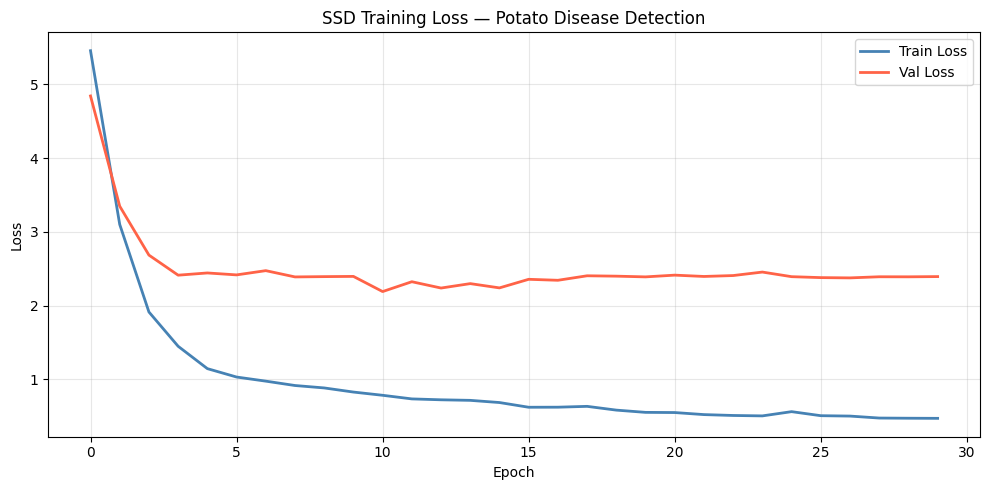

Loss curve saved!


In [5]:
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
plt.plot(history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('SSD Training Loss — Potato Disease Detection')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ssd_loss_curve.png', dpi=150)
plt.show()
print('Loss curve saved!')

## Step 8: Evaluation

In [14]:
!pip install torch torchvision --upgrade --quiet
import importlib, sys

# Clear all cached torch/torchvision modules
mods_to_remove = [k for k in sys.modules if 'torch' in k or 'torchvision' in k]
for mod in mods_to_remove:
    del sys.modules[mod]

print("torch/torchvision reinstalled! Now restart runtime and re-run from Step 3.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9

In [6]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

metric = MeanAveragePrecision(
    iou_thresholds=[0.5],
    class_metrics=True,
    box_format='xyxy'
)

print('Running inference on test set...')
with torch.no_grad():
    for imgs, targets in tqdm(test_loader, desc='Evaluating'):
        imgs = [img.to(DEVICE) for img in imgs]
        preds = model(imgs)

        for pred, target in zip(preds, targets):
            keep = pred['scores'] >= 0.1  # lowered from 0.4

            if keep.sum() == 0:
                pred_entry = {
                    'boxes':  torch.zeros((0, 4), dtype=torch.float32),
                    'scores': torch.zeros((0,),   dtype=torch.float32),
                    'labels': torch.zeros((0,),   dtype=torch.int64),
                }
            else:
                pred_entry = {
                    'boxes':  pred['boxes'][keep].cpu(),
                    'scores': pred['scores'][keep].cpu(),
                    'labels': pred['labels'][keep].cpu(),
                }

            target_entry = {
                'boxes':  target['boxes'].cpu(),
                'labels': target['labels'].cpu(),
            }

            # Update one image at a time for correct mAP calculation
            metric.update([pred_entry], [target_entry])

results = metric.compute()

precision = results.get('map_per_class',     torch.tensor([0.0])).mean().item()
recall    = results.get('mar_100_per_class', torch.tensor([0.0])).mean().item()
f1        = 2 * (precision * recall) / (precision + recall + 1e-8)

print('\n' + '=' * 50)
print('EVALUATION RESULTS (Test Set)')
print('=' * 50)
print(f'mAP@0.5:      {results["map_50"].item():.4f}')
print(f'mAP@0.5:0.95: {results["map"].item():.4f}')
print(f'Precision:    {precision:.4f}')
print(f'Recall:       {recall:.4f}')
print(f'F1 Score:     {f1:.4f}')
if 'map_per_class' in results:
    print('\nPer-Class mAP@0.5:')
    for i, cls in enumerate(CLASSES):
        if i < len(results['map_per_class']):
            print(f'  {cls}: {results["map_per_class"][i].item():.4f}')

Running inference on test set...


Evaluating: 100%|██████████| 5/5 [00:04<00:00,  1.03it/s]


EVALUATION RESULTS (Test Set)
mAP@0.5:      0.7838
mAP@0.5:0.95: 0.7838
Precision:    0.7838
Recall:       1.0000
F1 Score:     0.8788

Per-Class mAP@0.5:
  Early_Blight: 0.8401
  Late_Blight: 0.7275


## Step 9: Inference Speed

In [7]:
model.eval()
dummy = [torch.rand(3, IMG_SIZE, IMG_SIZE).to(DEVICE)]
for _ in range(10):
    with torch.no_grad(): _ = model(dummy)

N = 100
t0 = time.time()
for _ in range(N):
    with torch.no_grad(): _ = model(dummy)
elapsed_ms = (time.time() - t0) / N * 1000

torch.save(model.state_dict(), '/tmp/ssd_size.pth')
model_mb = os.path.getsize('/tmp/ssd_size.pth') / (1024 * 1024)

print('=' * 50)
print('INFERENCE METRICS (Thesis Table)')
print('=' * 50)
print(f'Inference Time: {elapsed_ms:.2f} ms/image')
print(f'FPS:            {1000/elapsed_ms:.1f}')
print(f'Model Size:     {model_mb:.2f} MB')
print(f'Parameters:     {sum(p.numel() for p in model.parameters()):,}')

INFERENCE METRICS (Thesis Table)
Inference Time: 15.01 ms/image
FPS:            66.6
Model Size:     8.76 MB
Parameters:     2,220,380


## Step 10: Visualize Predictions

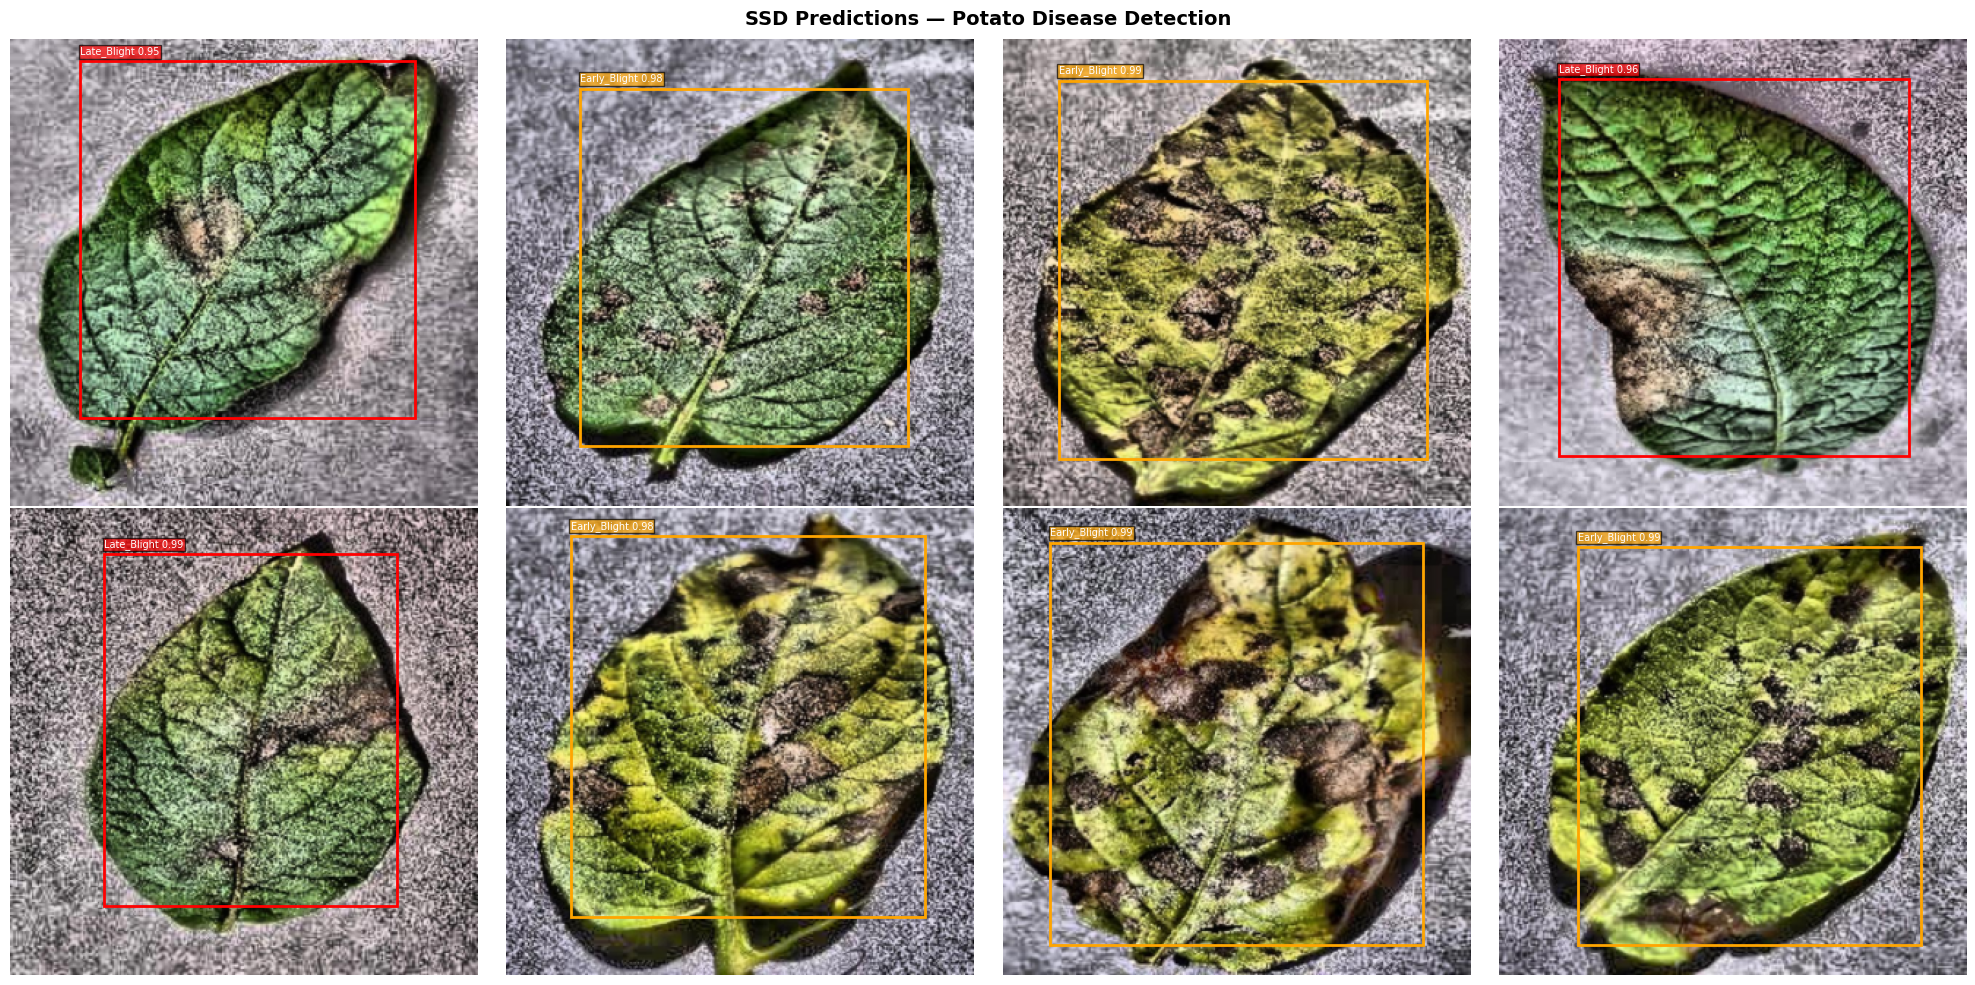

Saved to Drive!


In [8]:
CLASS_MAP = {i+1: cls for i, cls in enumerate(CLASSES)}
COLORS    = {'Early_Blight': 'orange', 'Late_Blight': 'red', 'Healthy': 'green'}

model.eval()
imgs_batch, _ = next(iter(test_loader))
with torch.no_grad():
    preds = model([img.to(DEVICE) for img in imgs_batch])

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, (img_t, pred) in enumerate(zip(imgs_batch[:8], preds[:8])):
    img_np = np.clip(img_t.permute(1,2,0).numpy(), 0, 1)
    ax = axes.flatten()[i]
    ax.imshow(img_np); ax.axis('off')
    keep = pred['scores'] >= CONF_THRESH
    for box, lbl, sc in zip(pred['boxes'][keep].cpu().numpy(),
                             pred['labels'][keep].cpu().numpy(),
                             pred['scores'][keep].cpu().numpy()):
        x1,y1,x2,y2 = box
        name  = CLASS_MAP.get(lbl, 'Unknown')
        color = COLORS.get(name, 'blue')
        ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,linewidth=2,edgecolor=color,facecolor='none'))
        ax.text(x1,max(y1-5,10),f'{name} {sc:.2f}',color='white',fontsize=7,
                bbox=dict(facecolor=color,alpha=0.7,pad=1))

plt.suptitle('SSD Predictions — Potato Disease Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ssd_predictions.png', dpi=150)
plt.show()
print('Saved to Drive!')

## Summary

In [9]:
print('=' * 55)
print('  SSD RESULTS SUMMARY')
print('=' * 55)
print(f'  Model:          SSDLite320 + MobileNetV3')
print(f'  Input Size:     {IMG_SIZE}x{IMG_SIZE}')
print(f'  Epochs:         {NUM_EPOCHS}')
print(f'  mAP@0.5:        {results["map_50"].item():.4f}')
print(f'  mAP@0.5:0.95:   {results["map"].item():.4f}')
print(f'  F1 Score:       {f1:.4f}')
print(f'  Inference Time: {elapsed_ms:.2f} ms/image')
print(f'  FPS:            {1000/elapsed_ms:.1f}')
print(f'  Model Size:     {model_mb:.2f} MB')
print('=' * 55)

  SSD RESULTS SUMMARY
  Model:          SSDLite320 + MobileNetV3
  Input Size:     320x320
  Epochs:         30
  mAP@0.5:        0.7838
  mAP@0.5:0.95:   0.7838
  F1 Score:       0.8788
  Inference Time: 15.01 ms/image
  FPS:            66.6
  Model Size:     8.76 MB
